# FreshMart Product Data — Exploratory Analysis

This notebook reproduces the original EDA on the FreshMart product catalogue (205 products, 6 columns) using the restructured project layout.

**Data source:** `data/raw/freshmart_products_csv.csv`  
**Cleaned pipeline:** see `scripts/run_pipeline.py` and `src/` for the reusable modules  
**Database:** the project defaults to SQLite (no server needed); see README for PostgreSQL setup

> **Path note:** the CSV path is resolved relative to this notebook file's location, so the notebook works regardless of which folder VS Code treats as the working directory.

In [9]:
import pandas as pd
from pathlib import Path

# Resolve the CSV path relative to this notebook file (works regardless of cwd)
NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
csv_path = (NOTEBOOK_DIR.parent / "data" / "raw" / "freshmart_products_csv.csv").resolve()

print(f"Notebook dir : {NOTEBOOK_DIR}")
print(f"CSV path     : {csv_path}")
print(f"CSV exists   : {csv_path.exists()}")

df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
df.head()

Notebook dir : c:\Users\jerda\Capstone-Project\notebooks
CSV path     : C:\Users\jerda\Capstone-Project\data\raw\freshmart_products_csv.csv
CSV exists   : True
Loaded 205 rows, 5 columns


,ProductID,ProductName,Category,Price,StockQuantity
0,1,Milk 1,Dairy,19.35,358.0
1,2,Cola 2,Beverages,9.99,81.0
2,3,Banana 3,Produce,30.33,112.0
3,4,Cream 4,Dairy,22.85,224.0
4,5,Cream 5,Dairy,3.85,97.0


In [10]:
# Missing values per column
df.isnull().sum()

ProductID        0
ProductName      0
Category         0
Price            5
StockQuantity    5
dtype: int64

In [11]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ProductID      205 non-null    int64  
 1   ProductName    205 non-null    str    
 2   Category       205 non-null    str    
 3   Price          200 non-null    float64
 4   StockQuantity  200 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 8.1 KB


In [12]:
# Derive StockValue = Price * StockQuantity
df["StockValue"] = df["Price"] * df["StockQuantity"]
df.head()

,ProductID,ProductName,Category,Price,StockQuantity,StockValue
0,1,Milk 1,Dairy,19.35,358.0,6927.30
1,2,Cola 2,Beverages,9.99,81.0,809.19
2,3,Banana 3,Produce,30.33,112.0,3396.96
3,4,Cream 4,Dairy,22.85,224.0,5118.40
4,5,Cream 5,Dairy,3.85,97.0,373.45


In [13]:
# Average price
df["Price"].mean()

np.float64(24.504299999999997)

In [14]:
# Total stock quantity
df["StockQuantity"].sum()

np.float64(52810.0)

In [15]:
# Category breakdown — note misspellings/variants in the raw data
print("Raw categories (before normalisation):")
print(df["Category"].value_counts())
print()
print("Unique raw categories:", sorted(df["Category"].unique()))

Raw categories (before normalisation):
Category
Beverages    43
Produce      42
Dairy        41
Bakery       38
Snacks       38
dairy         1
Bevarages     1
snakcs        1
Name: count, dtype: int64

Unique raw categories: ['Bakery', 'Bevarages', 'Beverages', 'Dairy', 'Produce', 'Snacks', 'dairy', 'snakcs']


## Data quality note

The raw CSV contains three category variants that should be merged into their canonical forms:

| Raw value | Canonical | Issue |
|-----------|-----------|-------|
| `dairy` | `Dairy` | lowercase |
| `Bevarages` | `Beverages` | typo |
| `snakcs` | `Snacks` | typo |

These are handled automatically by `src/data_loader.clean()` via the `CATEGORY_NORMALISATION` mapping in `src/config.py`. After cleaning, the dataset has 5 distinct categories.

In [16]:
# Use the project's cleaning function to see the normalised result
import sys
sys.path.insert(0, str(NOTEBOOK_DIR.parent))

from src.data_loader import clean
df_clean = clean(df.copy())

print("Categories after cleaning:")
print(df_clean["Category"].value_counts())
print()
print("Number of distinct categories:", df_clean["Category"].nunique())

Categories after cleaning:
Category
Beverages    44
Dairy        42
Produce      42
Snacks       39
Bakery       38
Name: count, dtype: int64

Number of distinct categories: 5


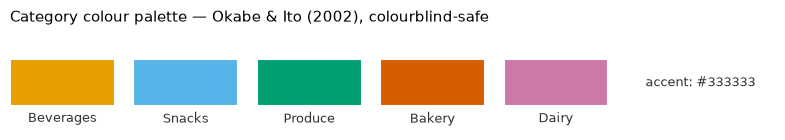

In [17]:
# Visualisation colour palette used across all project charts
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.config import CATEGORY_COLORS, CATEGORY_ORDER, PLOT_ACCENT

fig, ax = plt.subplots(figsize=(8, 1.5))
ax.set_xlim(0, len(CATEGORY_ORDER) + 1.2)
ax.set_ylim(0, 1)
ax.axis("off")

for i, cat in enumerate(CATEGORY_ORDER):
    ax.add_patch(
        mpatches.Rectangle(
            (i, 0.25), 0.85, 0.5,
            facecolor=CATEGORY_COLORS[cat],
            edgecolor="white",
            linewidth=1.5
        )
    )
    ax.text(i + 0.425, 0.12, cat, ha="center", va="center",
            fontsize=9, color="#333333")

ax.text(len(CATEGORY_ORDER) + 0.15, 0.5, f"accent: {PLOT_ACCENT}",
        ha="left", va="center", fontsize=9, color=PLOT_ACCENT)

ax.set_title(
    "Category colour palette — Okabe & Ito (2002), colourblind-safe",
    fontsize=11, loc="left", pad=10
)
plt.tight_layout()
plt.show()

## Visualisation

The charts below use the palette above. All five category colours are from the Okabe-Ito colourblind-safe palette; the accent (`#333333`) is used for non-categorical elements (mean reference lines, top-N ranking bars). See `src/visualise.py` for the plotting functions and README.md for the palette rationale.

- **Price distribution** — histogram + KDE of product prices with mean line
- **Category comparison** — three panels: count, average price, total stock value
- **Stock value vs. price** — scatter coloured by category (log y-axis)
- **Top 10 products** — horizontal bar ranking by stock value

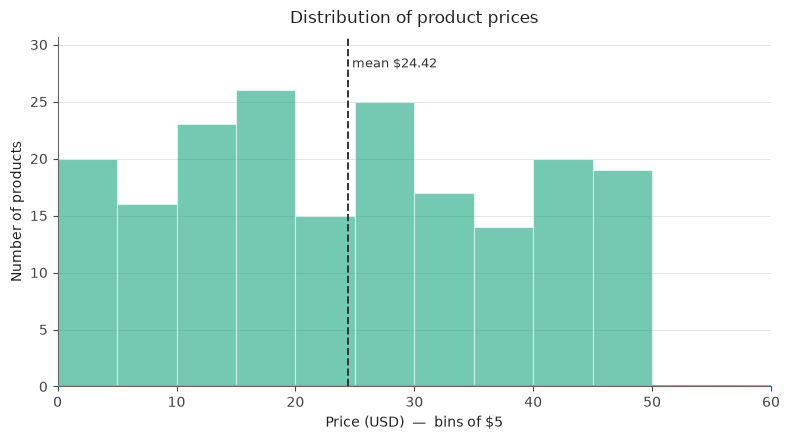

In [18]:
# Plot 1 — Price distribution
from src.visualise import plot_price_distribution

df_plot = df_clean[df_clean["Price"] > 0].copy()
fig = plot_price_distribution(df_plot)
plt.show()

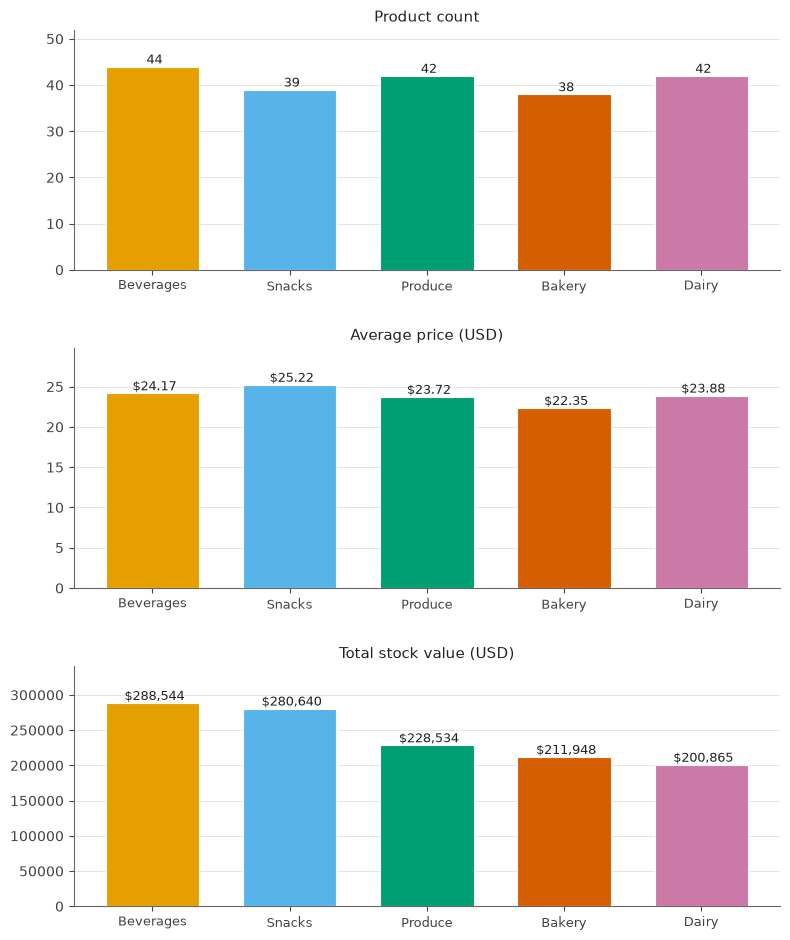

In [19]:
# Plot 2 — Category comparison (three panels)
from src.visualise import plot_category_comparison

fig = plot_category_comparison(df_clean)
plt.show()

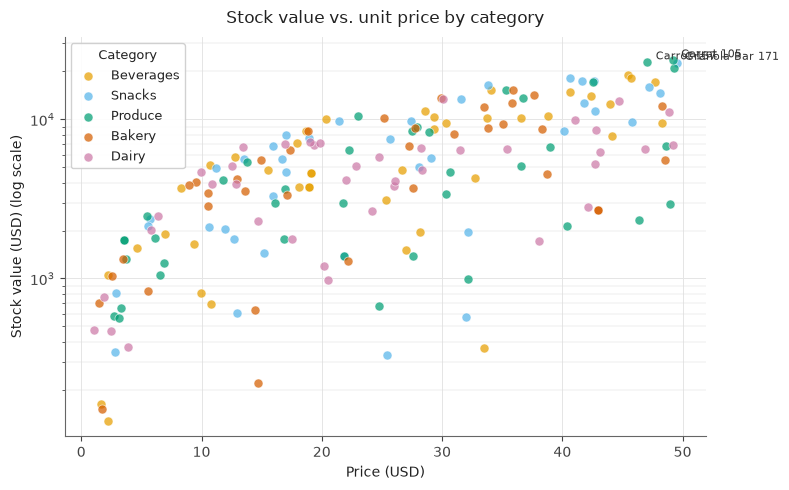

In [20]:
# Plot 3 — Stock value vs. price, coloured by category
from src.visualise import plot_value_vs_price

df_plot = df_clean[df_clean["Price"] > 0].copy()
fig = plot_value_vs_price(df_plot)
plt.show()

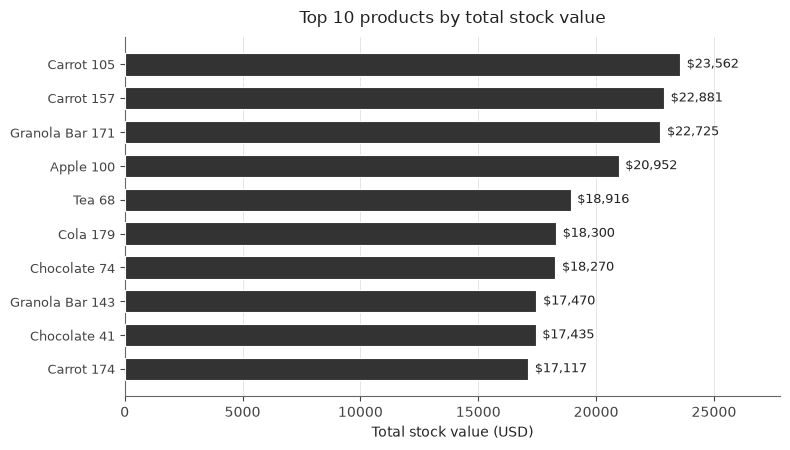

In [21]:
# Plot 4 — Top 10 products by stock value
from src.visualise import plot_top_products

df_plot = df_clean[df_clean["Price"] > 0].copy()
fig = plot_top_products(df_plot, n=10)
plt.show()

## Database

The original notebook used a local PostgreSQL connection with hardcoded credentials. The restructured project replaces this with:

- `src/database.py` — driver-agnostic layer (SQLite by default, PostgreSQL optional)
- `scripts/run_pipeline.py` — end-to-end pipeline that loads, cleans, analyses, and persists to SQLite

No credentials are needed for the default SQLite path. See `.env.example` and the README for the PostgreSQL option.